# Adapt-PCNN (MLP) — return-air temperature forecast

Physics-consistent MLP that forecasts **return-air temperature** (`RA_T`) on the
TDC2.0 data, ported from the [Adapt-PCNN paper](https://doi.org/10.1016/j.apenergy.2024.124637).
Self-contained under `rack_forecast.pcnn`; **separate** from the rack-power
forecasting pipeline.

Per-step update: `T[t+1] = T[t] + D/div - cool + heat`, where `D` is an MLP
residual and the physics term uses **adaptive** softplus coefficients:
`cool = coeff_a·(RA_T-SA_T)·SA_V/100`, `heat = coeff_b·ITE_P/100`.

**Rollout = their design:** warm-start autoregressive — exogenous drivers
(`SA_T, SA_V, OA_T, OA_H, ITE_P`) stay pinned to REAL data over the horizon and
only `RA_T` is fed back. This is a **conditional** forecast (assumes the future
driver trajectory is known), i.e. a thermal-dynamics-fidelity test, not open-loop
forecasting.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Only imports from the isolated pcnn subpackage.
from rack_forecast.pcnn import (
    PCNNConfig, build_pcnn_dataset, fit_normalizer, month_split,
    train_pcnn, rollout_evaluate, predict_window_trace,
    run_baselines, BASELINE_MODELS, FEATURE_ORDER, DEVICE,
)
print('device:', DEVICE)

device: cuda


## 1. Config

Feature order is fixed at `[SA_T, SA_V, OA_T, OA_H, ITE_P, RA_T]`; `RA_T` (index -1) is the target. 1 step = 1 min, horizon = 15 steps = **15 min**.

In [2]:
cfg = PCNNConfig(
    target_rack='R0605-PA',
    resample='1min',
    warm_start=1,      # real RA_T steps to seed the autoregressive state
    horizon=15,        # 15 steps @ 1 min = 15-minute forecast
    n_epochs=50,       # ~2.5 s/epoch on GPU; raise toward 100 (paper) for a bit more
    lr=0.005,
    overlapping_distance=30,
    seed=0,
    verbose=1,
)
cfg

PCNNConfig(target_rack='R0605-PA', resample='1min', warm_start=1, horizon=15, overlapping_distance=30, validation_percentage=0.2, mlp_hidden_size=128, mlp_num_layers=3, activation=1, division_factor=10.0, n_epochs=50, batch_size=256, lr=0.005, seed=0, verbose=1, run_id='pcnn_001', feature_names=['SA_T', 'SA_V', 'OA_T', 'OA_H', 'ITE_P', 'RA_T'], supply_T_col=0, supply_m_col=1, power_col=4, temperature_col=5, inputs_D=[2, 3, 5])

## 2. Build the 6-signal dataset

Light loader (4 GW streams + rack kW) — never triggers the power pipeline's full-mode 182-feature load.

In [3]:
data = build_pcnn_dataset(cfg)
print('shape:', data.shape, '| range:', data.index.min(), '->', data.index.max())
print('\nFeature mapping (PCNN name -> NTU sensor):')
for name, src in zip(FEATURE_ORDER,
        ['SAT1 (GW-1)', 'SAAV1 (GW-1)', 'OATH1 temp (GW-2)',
         'OATH1 humidity (GW-2)', f'{cfg.target_rack} PDU kW', 'RATH1 temp (GW-2) [TARGET]']):
    print(f'  {name:6s} <- {src}')
data.head()

shape: (260625, 6) | range: 2022-09-01 00:00:00 -> 2023-02-28 23:59:00

Feature mapping (PCNN name -> NTU sensor):
  SA_T   <- SAT1 (GW-1)
  SA_V   <- SAAV1 (GW-1)
  OA_T   <- OATH1 temp (GW-2)
  OA_H   <- OATH1 humidity (GW-2)
  ITE_P  <- R0605-PA PDU kW
  RA_T   <- RATH1 temp (GW-2) [TARGET]


,SA_T,SA_V,OA_T,OA_H,ITE_P,RA_T
timestamp,,,,,,
2022-09-01 00:00:00,29.86,2.620,30.50,67.0,0.5385,34.5
2022-09-01 00:01:00,29.86,0.600,30.50,67.0,0.5230,34.5
2022-09-01 00:02:00,29.86,0.660,30.50,67.0,0.5050,34.5
2022-09-01 00:03:00,29.86,0.615,30.45,67.0,0.4830,34.5
2022-09-01 00:04:00,29.86,0.650,30.45,67.0,0.4905,34.5


## 3. Normalize (min-max to [0,1]) + chronological split

Min-max is required — the physics `/100` scalings assume [0,1]-ranged inputs. Fit on train only; last calendar month is the test set.

In [4]:
train_df, test_df, months = month_split(data)
print(f'train={len(train_df):,}  test={len(test_df):,}  test month={months[-1]}')

norm = fit_normalizer(train_df)
X_train = norm.transform(train_df)
X_test  = norm.transform(test_df)
print('normalized train range:', round(float(X_train.min()),3), '..', round(float(X_train.max()),3))

train=220,305  test=40,320  test month=2023-02
normalized train range: 0.0 .. 1.0


## 4. Train

Fixed-length windows (`warm_start + horizon`), MSE on the horizon predictions, best-validation checkpoint returned.

In [5]:
model, best_val = train_pcnn(X_train, cfg)
print(f'best validation MSE (scaled): {best_val:.3e}')

  epochs:   0%|          | 0/50 [00:00<?, ?ep/s]

  epochs:   0%|          | 0/50 [00:02<?, ?ep/s, best=inf, train=1.71e-01, val=1.94e-03]

  epochs:   2%|▏         | 1/50 [00:02<01:51,  2.27s/ep, best=inf, train=1.71e-01, val=1.94e-03]

  epochs:   2%|▏         | 1/50 [00:04<01:51,  2.27s/ep, best=1.94e-03, train=9.09e-03, val=4.19e-03]

  epochs:   4%|▍         | 2/50 [00:04<01:37,  2.02s/ep, best=1.94e-03, train=9.09e-03, val=4.19e-03]

...

  epochs:  96%|█████████▌| 48/50 [01:48<00:04,  2.06s/ep, best=1.50e-05, train=3.10e-05, val=1.56e-05]

  epochs:  98%|█████████▊| 49/50 [01:48<00:02,  2.10s/ep, best=1.50e-05, train=3.10e-05, val=1.56e-05]

  epochs:  98%|█████████▊| 49/50 [01:50<00:02,  2.10s/ep, best=1.50e-05, train=3.08e-05, val=1.48e-05]

  epochs: 100%|██████████| 50/50 [01:50<00:00,  2.19s/ep, best=1.50e-05, train=3.08e-05, val=1.48e-05]

best validation MSE (scaled): 1.480e-05


## 5. Evaluate — 15-minute rollout on the held-out month

Metrics in physical units (°C).

In [6]:
res = rollout_evaluate(model, X_test, cfg, norm)
m = res['metrics']
print(f"windows scored: {res['n_windows']}")
metrics_df = pd.DataFrame([m], index=['Adapt_PC_MLP']).round(4)
metrics_df

windows scored: 2520


,MAE,RMSE,MAPE(%),R2
Adapt_PC_MLP,0.0746,0.1151,0.2353,0.994


> **Reading these numbers:** RMSE is in °C. Because the drivers are real
> future data (their design), a low error here reflects thermal-dynamics fidelity
> given known inputs — not open-loop forecasting skill. See the note at the top.

## 6. Baseline comparison — 5 black-box models, same task, same information

Fair ablation: each baseline (linear, xgboost, lstm, cnn1d, transformer) gets the
**same information** PCNN uses — all drivers across the window + the seed RA_T,
future RA_T masked — and predicts the **same 15 RA_T values on the same test
windows** (verified: identical targets). The only difference from PCNN is the
absence of the physics structure, so any gap reflects the physics, not the inputs.

These are DIRECT multi-step forecasts (predict all 15 steps at once); the DL
architectures are the power-pipeline model classes reused read-only with
`n_out=horizon`. Nothing trains through the power pipeline.

In [7]:
baseline_res = run_baselines(X_train, X_test, cfg, norm, verbose=True)

[baseline:linear] training...

           MAE=0.0724  RMSE=0.1138  R2=0.9941
[baseline:xgboost] training...


           MAE=0.0974  RMSE=0.1467  R2=0.9902
[baseline:lstm] training...


           MAE=0.0918  RMSE=0.1382  R2=0.9913
[baseline:cnn1d] training...


           MAE=0.0834  RMSE=0.1261  R2=0.9927
[baseline:transformer] training...


           MAE=0.1016  RMSE=0.1434  R2=0.9906


In [8]:
# Combined table: PCNN + 5 baselines, sorted by RMSE (best first).
rows = {'Adapt_PC_MLP (physics)': res['metrics']}
rows.update({name: r['metrics'] for name, r in baseline_res.items()})
compare = pd.DataFrame(rows).T[['MAE', 'RMSE', 'MAPE(%)', 'R2']].sort_values('RMSE').round(4)
compare

,MAE,RMSE,MAPE(%),R2
linear,0.0724,0.1138,0.2277,0.9941
Adapt_PC_MLP (physics),0.0746,0.1151,0.2353,0.9940
cnn1d,0.0834,0.1261,0.2630,0.9927
lstm,0.0918,0.1382,0.2895,0.9913
transformer,0.1016,0.1434,0.3191,0.9906
xgboost,0.0974,0.1467,0.3045,0.9902


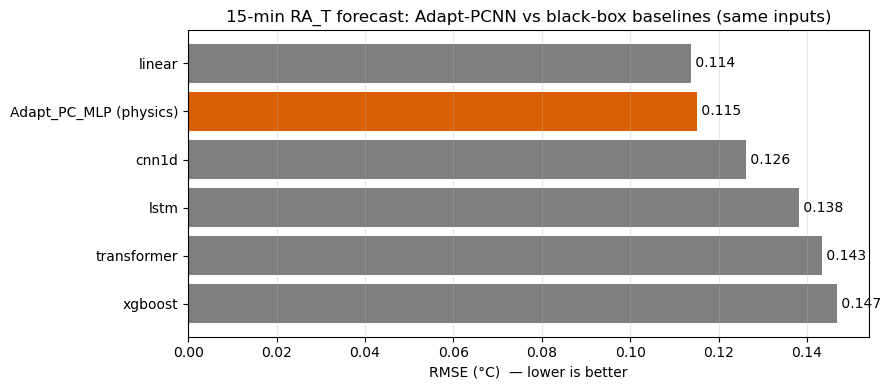

In [9]:
# Bar chart: RMSE by model (PCNN highlighted).
order = compare.index.tolist()
vals = compare['RMSE'].values
colors = ['#d95f02' if 'PC_MLP' in m else '#7f7f7f' for m in order]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(range(len(order)), vals, color=colors)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.invert_yaxis(); ax.set_xlabel('RMSE (°C)  — lower is better')
ax.set_title('15-min RA_T forecast: Adapt-PCNN vs black-box baselines (same inputs)')
for i, v in enumerate(vals):
    ax.text(v, i, f' {v:.3f}', va='center')
ax.grid(axis='x', alpha=.3); plt.tight_layout(); plt.show()

> **How to read this:** at a **15-min** horizon with the **real future drivers
> supplied and full training data**, this is an easy regime where a good black-box
> model can match or beat PCNN — the physics prior helps most where data is scarce
> or the horizon is long (the paper's varying-training-size / varying-horizon
> experiments). PCNN's real edge is *robustness*, not necessarily best-case accuracy
> on an easy setting. Raise `cfg.horizon` (e.g. 60, 240) or cut training data to see
> the gap shift in PCNN's favour.

## 7. Plots

### 7a. One window: predicted vs actual RA_T over the 15-min horizon

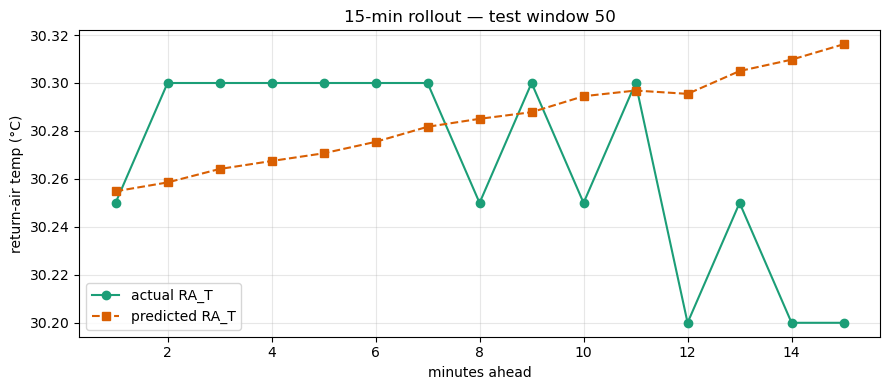

In [10]:
# Pick a representative test window (non-overlapping, same as evaluation).
w = min(50, res['n_windows'] - 1)
start = w * cfg.window_len
window = X_test[start:start + cfg.window_len]
trace = predict_window_trace(model, window, cfg, norm)

t = np.arange(1, cfg.horizon + 1)   # minutes ahead
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, trace['actual'], 'o-', label='actual RA_T', color='#1b9e77')
ax.plot(t, trace['pred'], 's--', label='predicted RA_T', color='#d95f02')
ax.set_xlabel('minutes ahead'); ax.set_ylabel('return-air temp (°C)')
ax.set_title(f'15-min rollout — test window {w}'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 7b. Adaptive coefficients across the horizon

The softplus heads make `coeff_a` (cooling) and `coeff_b` (heating) vary with operating condition — the paper's core idea vs. fixed coefficients. Both stay strictly positive.

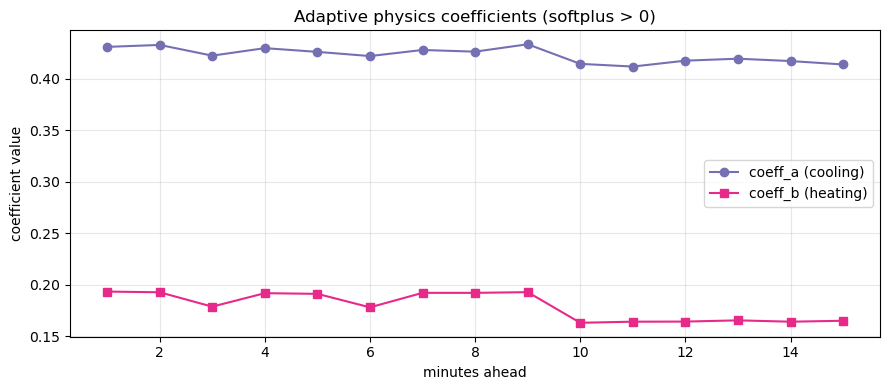

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, trace['coeff_a'], 'o-', label='coeff_a (cooling)', color='#7570b3')
ax.plot(t, trace['coeff_b'], 's-', label='coeff_b (heating)', color='#e7298a')
ax.set_xlabel('minutes ahead'); ax.set_ylabel('coefficient value')
ax.set_title('Adaptive physics coefficients (softplus > 0)'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 7c. Error growth by horizon step

How the mean absolute error accumulates over the 15-min recursive rollout, across all test windows.

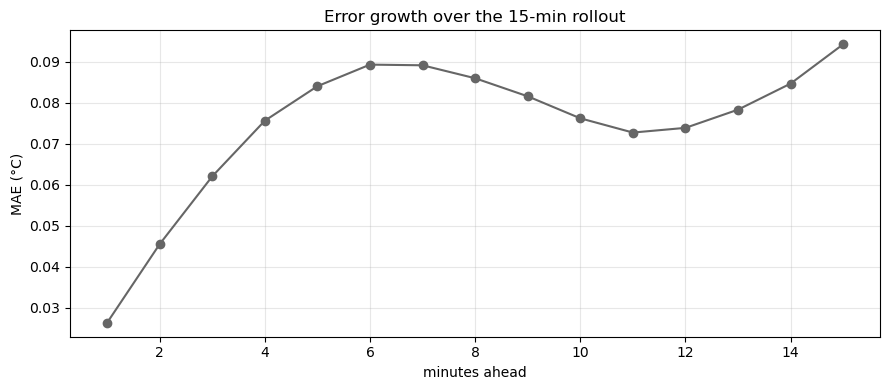

MAE step 1: 0.0263 °C  |  MAE step 15: 0.0943 °C


In [12]:
abs_err = np.abs(res['preds'] - res['actuals'])     # (n_windows, horizon)
mae_by_step = abs_err.mean(axis=0)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, mae_by_step, 'o-', color='#666666')
ax.set_xlabel('minutes ahead'); ax.set_ylabel('MAE (°C)')
ax.set_title('Error growth over the 15-min rollout'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print('MAE step 1:', round(float(mae_by_step[0]),4), '°C  |  MAE step 15:',
      round(float(mae_by_step[-1]),4), '°C')

---
### Notes
- **Isolation:** this notebook imports only from `rack_forecast.pcnn`; it does not
  touch the rack-power pipeline.
- **ITE_P = single rack kW** (`R0605-PA`) as the load proxy. Summing all racks for a
  true room-level load is a one-line change in `pcnn/data.py`.
- **One rollout (their design).** A frozen-driver ("no future info") variant could be
  added later behind a config flag.